# Exploratory Data Analysis — Superstore Dataset

Dataset: `Superstore_Orders.csv` — 9,994 retail order line items (2016–2019) with sales, profit, discount, category, region, and customer segment data.

## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(color_codes=True)
import warnings
warnings.filterwarnings("ignore")

In [1]:
df = pd.read_csv('Superstore_Orders.csv', parse_dates=['Order Date', 'Ship Date'])
df.head()

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID    Customer Name    Segment Country/Region             City       State  Postal Code Region       Product ID         Category Sub-Category                                                 Product Name     Sales  Quantity  Discount    Profit
0       1  CA-2018-152156 2018-11-08 2018-11-11    Second Class    CG-12520      Claire Gute   Consumer  United States        Henderson    Kentucky      42420.0  South  FUR-BO-10001798        Furniture    Bookcases                            Bush Somerset Collection Bookcase  261.9600         2      0.00   41.9136
1       2  CA-2018-152156 2018-11-08 2018-11-11    Second Class    CG-12520      Claire Gute   Consumer  United States        Henderson    Kentucky      42420.0  South  FUR-CH-10000454        Furniture       Chairs  Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back  731.9400         3      0.00  219.5820
2       3  CA-2018-138688 2018-06-12 2018-06-16    S

## 2. Basic Structure

In [1]:
df.shape

(9994, 21)

In [1]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9994 non-null   int64         
 1   Order ID        9994 non-null   str           
 2   Order Date      9994 non-null   datetime64[us]
 3   Ship Date       9994 non-null   datetime64[us]
 4   Ship Mode       9994 non-null   str           
 5   Customer ID     9994 non-null   str           
 6   Customer Name   9994 non-null   str           
 7   Segment         9994 non-null   str           
 8   Country/Region  9994 non-null   str           
 9   City            9994 non-null   str           
 10  State           9994 non-null   str           
 11  Postal Code     9983 non-null   float64       
 12  Region          9994 non-null   str           
 13  Product ID      9994 non-null   str           
 14  Category        9994 non-null   str           
 15  Sub-Category   

In [1]:
df.describe()

            Row ID                  Order Date                   Ship Date   Postal Code         Sales     Quantity     Discount       Profit
count  9994.000000                        9994                        9994   9983.000000   9994.000000  9994.000000  9994.000000  9994.000000
mean   4997.500000  2018-04-30 10:03:51.979187  2018-05-04 09:03:29.645787  55245.233297    229.858001     3.789574     0.156203    28.656896
min       1.000000         2016-01-03 00:00:00         2016-01-07 00:00:00   1040.000000      0.444000     1.000000     0.000000 -6599.978000
25%    2499.250000         2017-05-23 00:00:00         2017-05-27 00:00:00  23223.000000     17.280000     2.000000     0.000000     1.728750
50%    4997.500000         2018-06-26 00:00:00         2018-06-29 00:00:00  57103.000000     54.490000     3.000000     0.200000     8.666500
75%    7495.750000         2019-05-14 00:00:00         2019-05-18 00:00:00  90008.000000    209.940000     5.000000     0.200000    29.364000
max   

## 3. Data Quality Checks

In [1]:
df.isnull().sum()[df.isnull().sum() > 0]

Postal Code    11

In [1]:
df.duplicated().sum()

0

Only `Postal Code` has missing values (11 rows), and there are no duplicate rows. Not a concern for the sales/profit analysis below.

## 4. Key Business Metrics (KPIs)

In [1]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = total_profit / total_sales
avg_discount = df['Discount'].mean()
total_orders = df['Order ID'].nunique()

print(f"Total Sales: {total_sales:,.2f}")
print(f"Total Profit: {total_profit:,.2f}")
print(f"Profit Margin: {profit_margin:.2%}")
print(f"Avg Discount: {avg_discount:.2%}")
print(f"Unique Orders: {total_orders}")
print(f"Total Line Items: {len(df)}")

Total Sales: 2,297,200.86
Total Profit: 286,397.02
Profit Margin: 12.47%
Avg Discount: 15.62%
Unique Orders: 5009
Total Line Items: 9994

## 5. Categorical Breakdowns

In [1]:
df['Category'].value_counts()

Category
Office Supplies    6026
Furniture          2121
Technology         1847

In [1]:
df['Region'].value_counts()

Region
West       3203
East       2848
Central    2323
South      1620

In [1]:
df['Segment'].value_counts()

Segment
Consumer       5191
Corporate      3020
Home Office    1783

## 6. Sales & Profit by Category

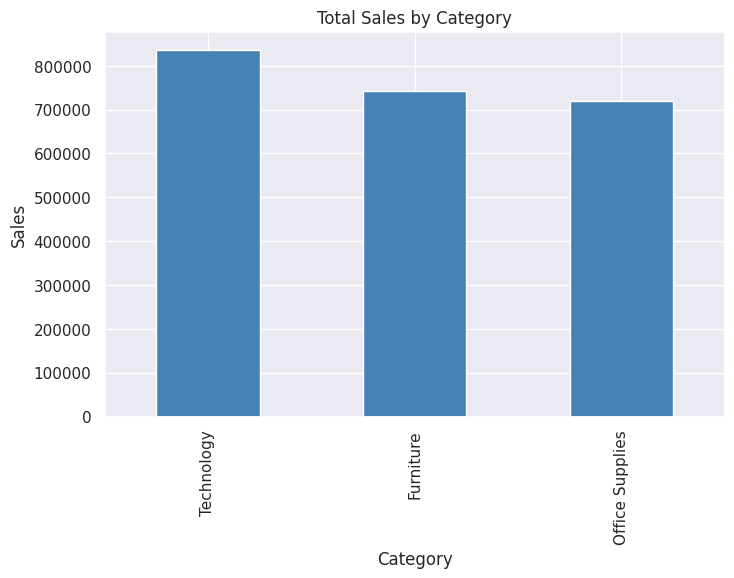

In [1]:
plt.figure(figsize=(8,5))
df.groupby('Category')['Sales'].sum().sort_values(ascending=False).plot(kind='bar', color='steelblue')
plt.title('Total Sales by Category')
plt.ylabel('Sales')
plt.show()

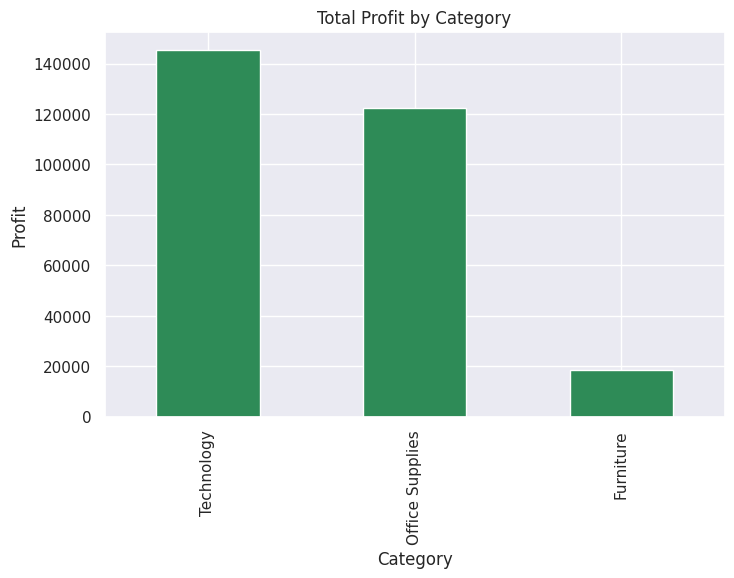

In [1]:
plt.figure(figsize=(8,5))
df.groupby('Category')['Profit'].sum().sort_values(ascending=False).plot(kind='bar', color='seagreen')
plt.title('Total Profit by Category')
plt.ylabel('Profit')
plt.show()

## 7. Sales & Profit by Sub-Category

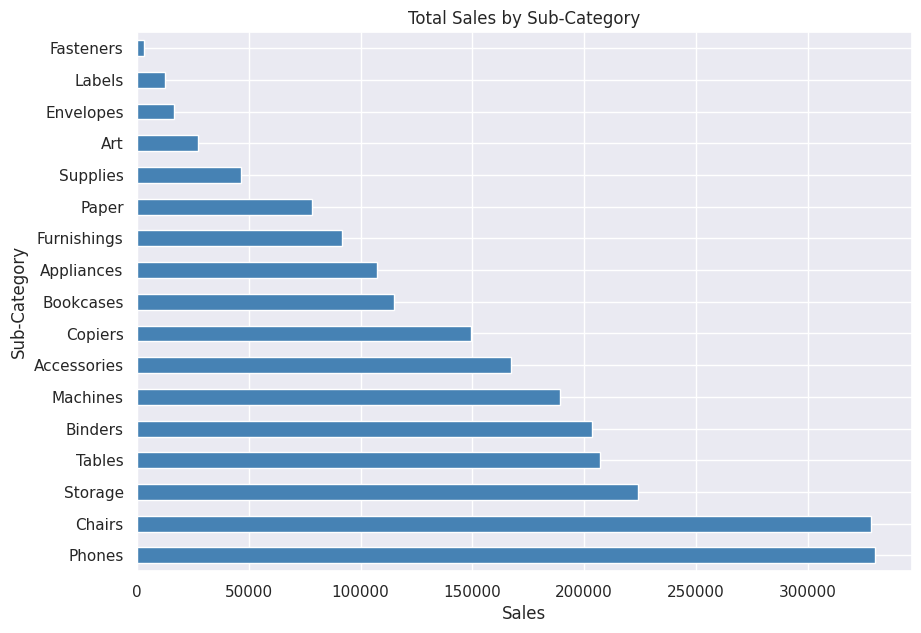

In [1]:
plt.figure(figsize=(10,7))
df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).plot(kind='barh', color='steelblue')
plt.title('Total Sales by Sub-Category')
plt.xlabel('Sales')
plt.show()

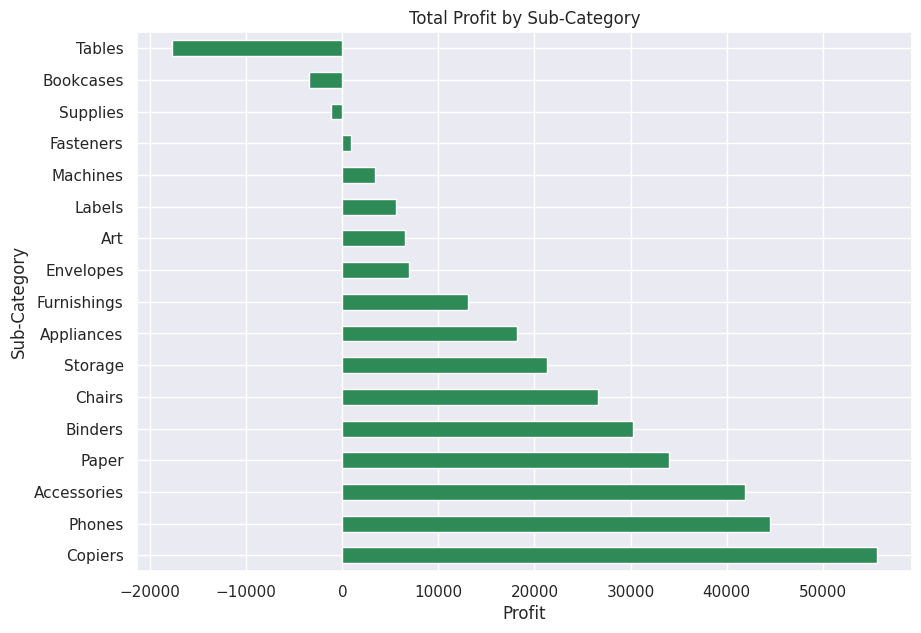

In [1]:
plt.figure(figsize=(10,7))
df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False).plot(kind='barh', color='seagreen')
plt.title('Total Profit by Sub-Category')
plt.xlabel('Profit')
plt.show()

**Tables** stand out as the biggest problem: they're a Furniture sub-category with meaningfully negative total profit despite having sales, largely driven by heavy discounting (see Section 9).

## 8. Regional & Segment Analysis

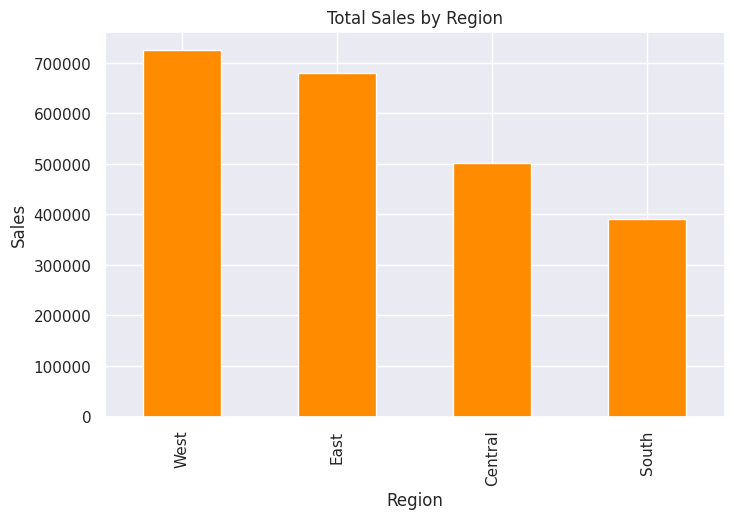

In [1]:
plt.figure(figsize=(8,5))
df.groupby('Region')['Sales'].sum().sort_values(ascending=False).plot(kind='bar', color='darkorange')
plt.title('Total Sales by Region')
plt.ylabel('Sales')
plt.show()

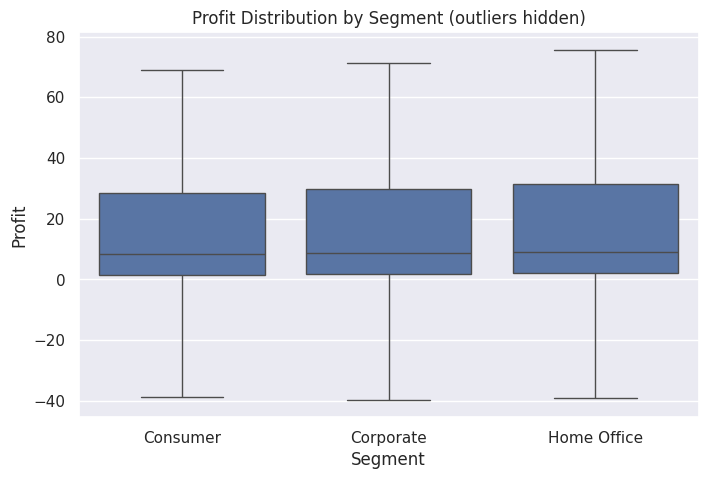

In [1]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Segment', y='Profit', data=df, showfliers=False)
plt.title('Profit Distribution by Segment (outliers hidden)')
plt.show()

## 9. Discount vs Profit

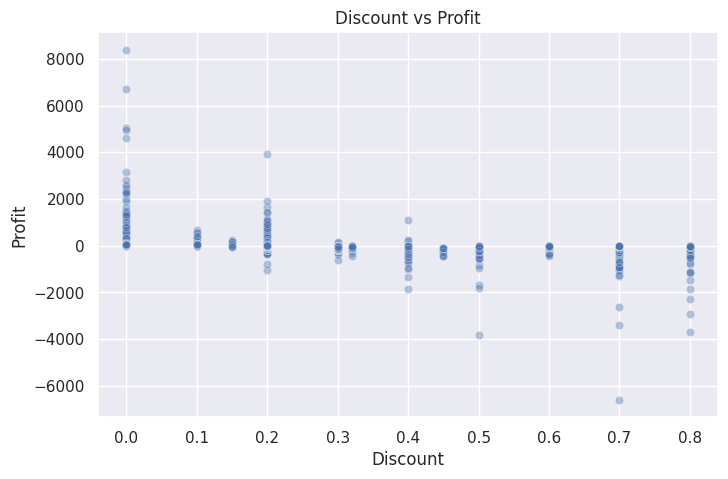

In [1]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Discount', y='Profit', data=df, alpha=0.4)
plt.title('Discount vs Profit')
plt.show()

In [1]:
discount_profit_corr = df['Discount'].corr(df['Profit'])
print(f"Correlation between Discount and Profit: {discount_profit_corr:.4f}")

Correlation between Discount and Profit: -0.2195

There's a clear negative relationship — heavier discounts are strongly associated with losses. Nearly every point below the zero-profit line clusters at high discount rates.

## 10. Sales Trend Over Time

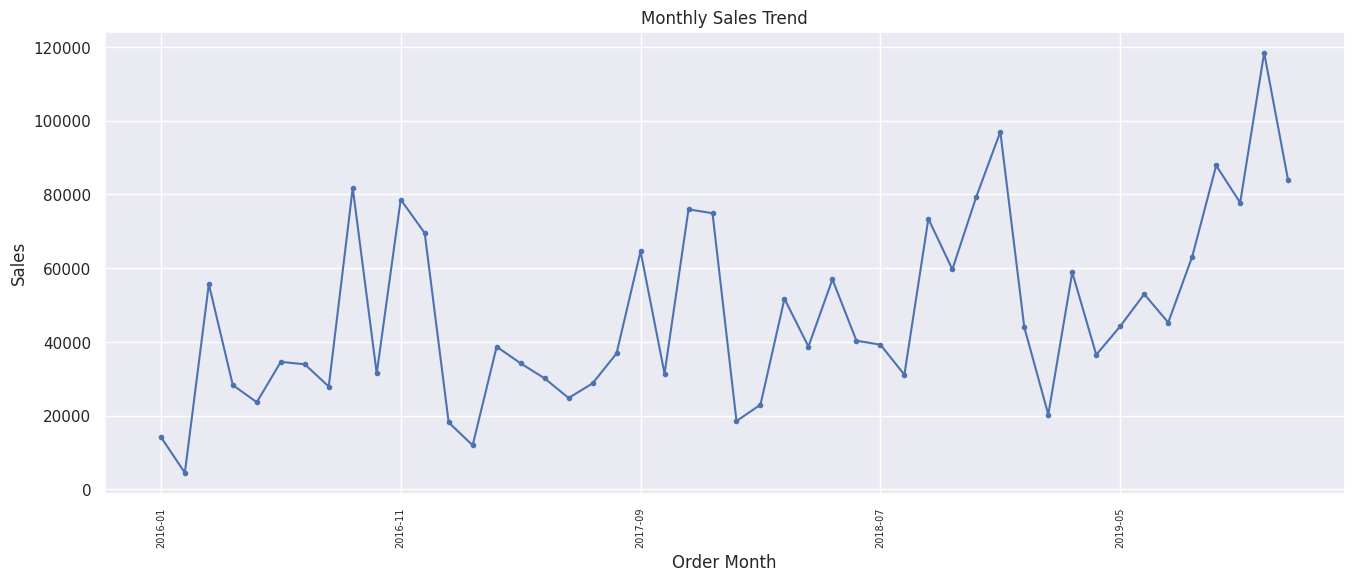

In [1]:
df['Order Month'] = df['Order Date'].dt.to_period('M').astype(str)
monthly_sales = df.groupby('Order Month')['Sales'].sum()

plt.figure(figsize=(16,6))
monthly_sales.plot(kind='line', marker='o', markersize=3)
plt.title('Monthly Sales Trend')
plt.ylabel('Sales')
plt.xticks(rotation=90, fontsize=7)
plt.show()

## 11. Shipping & Geography

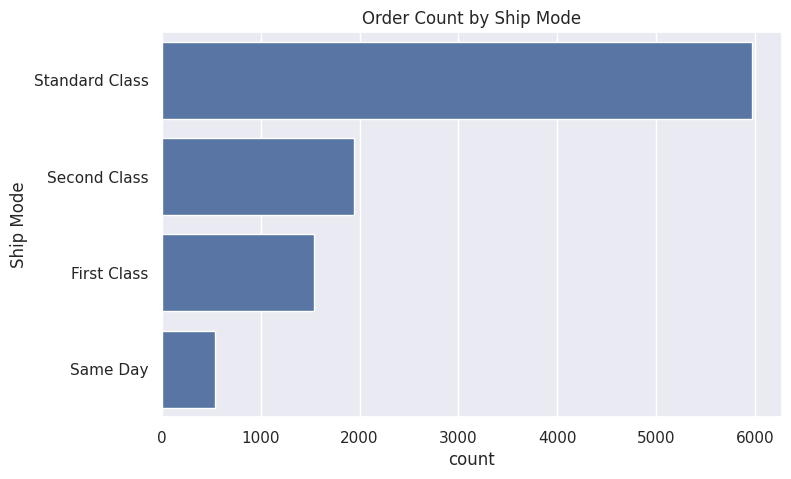

In [1]:
plt.figure(figsize=(8,5))
sns.countplot(y='Ship Mode', data=df, order=df['Ship Mode'].value_counts().index)
plt.title('Order Count by Ship Mode')
plt.show()

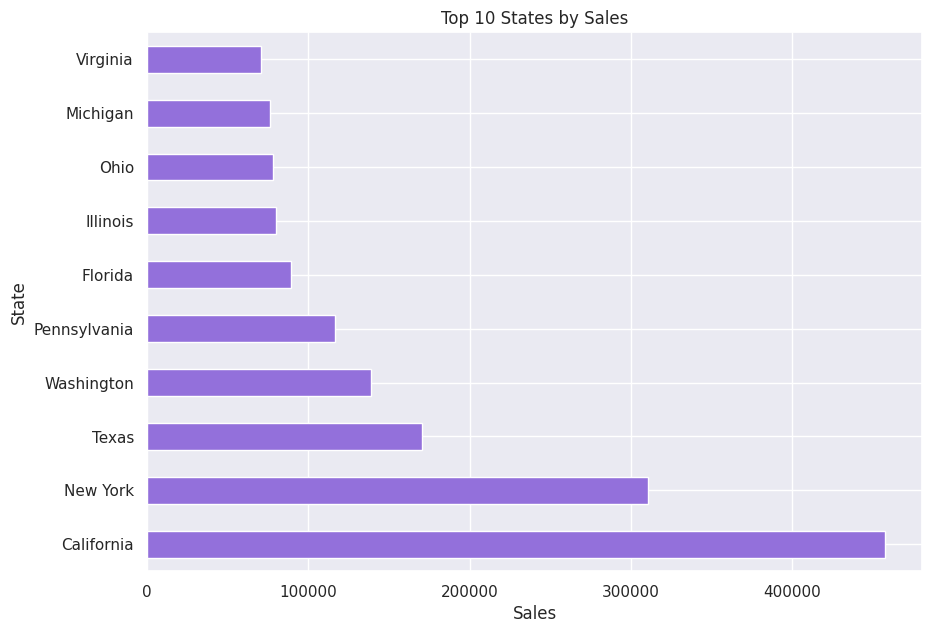

In [1]:
plt.figure(figsize=(10,7))
df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10).plot(kind='barh', color='mediumpurple')
plt.title('Top 10 States by Sales')
plt.xlabel('Sales')
plt.show()

## 12. Loss-Making Products

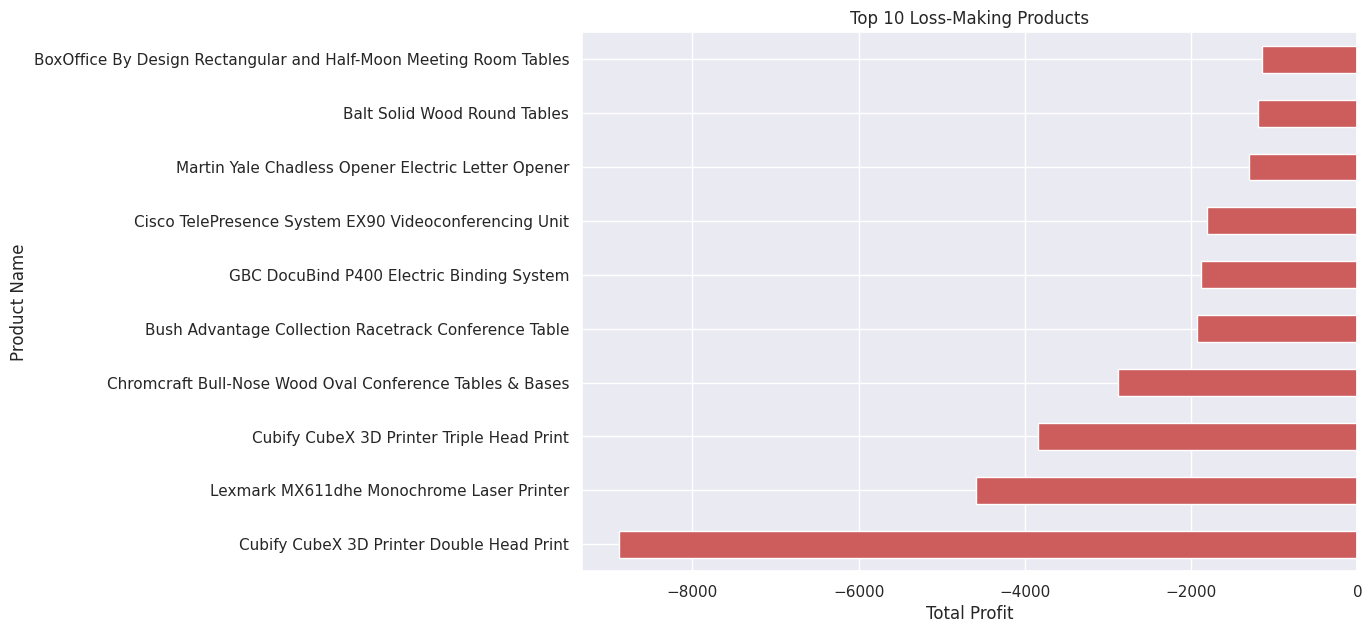

In [1]:
plt.figure(figsize=(10,7))
df.groupby('Product Name')['Profit'].sum().sort_values().head(10).plot(kind='barh', color='indianred')
plt.title('Top 10 Loss-Making Products')
plt.xlabel('Total Profit')
plt.show()

## 13. Correlation Analysis

In [1]:
numeric_cols = ['Sales','Quantity','Discount','Profit']
corr = df[numeric_cols].corr()
corr

             Sales  Quantity  Discount    Profit
Sales     1.000000  0.200795 -0.028190  0.479064
Quantity  0.200795  1.000000  0.008623  0.066253
Discount -0.028190  0.008623  1.000000 -0.219487
Profit    0.479064  0.066253 -0.219487  1.000000

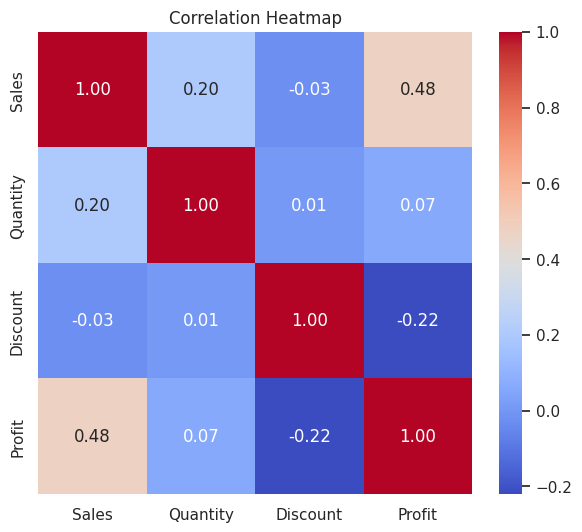

In [1]:
plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## 14. Summary

- **9,994 order line items, 5,009 unique orders** spanning 2016–2019; only `Postal Code` has missing values, no duplicates.
- **Total Sales: $2,297,200.86** | **Total Profit: $286,397.02** | **Profit Margin: 12.47%** | **Average Discount: 15.62%**.
- **Technology** and **Office Supplies** are the biggest profit drivers by category; **Tables** stands out as a consistently loss-making sub-category.
- **Discount and Profit are negatively correlated** — heavy discounting is strongly associated with unprofitable orders, and nearly all the biggest loss-making products carry high discount rates.
- The **West and East regions** lead in total sales; **Consumer** is the largest customer segment by volume.
- Monthly sales show a clear **seasonal pattern**, with November/December consistently the strongest months each year.